## Install and Import required libraries:

In [1]:
!pip install numpy pandas scikit-learn tensorflow keras matplotlib seaborn openpyxl scikeras

In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Get dataset files mitbih_train and mitbig_test

In [6]:
from google.colab import drive
drive.mount('/content/gdrive')

train = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/ML coursework/mitbih_train.csv', header=None)
test = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/ML coursework/mitbih_test.csv', header=None)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [7]:
print(f"Data Shape: {train.shape}")
print({test.shape})
print(train.iloc[:, -1].value_counts())
train.head()

Data Shape: (87554, 188)
{(21892, 188)}
187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Check for missing data in dataset

In [11]:
print("Missing values per column:\n", train.isnull().sum())
print("Number of columns with misisng values: ", np.count_nonzero(train.isnull().any(axis=1)))

Missing values per column:
 0      0
1      0
2      0
3      0
4      0
      ..
183    0
184    0
185    0
186    0
187    0
Length: 188, dtype: int64
Number of columns with misisng values:  0


## Normalisation and Encoding:

In [12]:
# Split features (first 187 columns) and labels (last column)
x_train = train.iloc[:, :-1].values
x_test  = test.iloc[:, :-1].values

# Labels are already 0-4 so no Encoding needed, just cast to int
y_train = train.iloc[:, -1].values.astype(int)
y_test  = test.iloc[:, -1].values.astype(int)

### Suffle Data

In [13]:
# Shuffle data before splitting to avoid class bias
x_train, y_train = shuffle(x_train, y_train, random_state=42)
print("y_train sample:", y_train[:20])

y_train sample: [0 0 0 0 4 0 0 4 4 0 0 0 0 0 0 0 1 0 0 0]


In [14]:
# Standardise features using z-score normalisation
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)  # fit on train only
x_test  = scaler.transform(x_test)

# Reshape to (N, 187, 1) — required format for 1D CNN input
x_train = x_train.reshape(-1, 187, 1)
x_test = x_test.reshape(-1, 187, 1)

print(x_train.shape)
print(x_test.shape)

(87554, 187, 1)
(21892, 187, 1)


## 1D CNN Arcitechture

### Build function

In [15]:
# 1D CNN architecture for multiclass classification
def build_1d_cnn(filters=64, kernel_size=5, dropout=0.3, learning_rate=1e-3, num_blocks=2):
  inputs = keras.Input(shape=(187, 1))
  x = inputs
  for i in range(num_blocks):
      x = layers.Conv1D(filters * (i + 1), kernel_size, padding='same')(x)
      x = layers.BatchNormalization()(x) # BatchNormalization stabilises training
      x = layers.ReLU()(x)
      x = layers.MaxPooling1D(pool_size=2)(x)
  x = layers.Flatten()(x)
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(dropout)(x)  # Dropout prevents overfitting
  outputs = layers.Dense(5, activation='softmax')(x)
  model = keras.Model(inputs, outputs)
  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )
  return model

### Random search Hyperparameter

In [16]:
# Define hyperparameter search space for random search
param_space = {
    'filters':       [32, 64, 128],
    'kernel_size':   [3, 5, 7],
    'dropout':       [0.2, 0.3, 0.5],
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'num_blocks':    [2, 3],
}

# 8 random combinations sampled to balance search coverage vs compute time
def sample_params(space, n):
    return [
        {k: random.choice(v) for k, v in space.items()}
        for _ in range(n)
    ]

random.seed(42)
candidates = sample_params(param_space, n=8)


### Random search with 5-fold cross-validation

In [17]:
# Each candidate hyperparameter set is evaluated across all 5 folds
N_SPLITS  = 5
EPOCHS    = 30
BATCH     = 256
PATIENCE  = 5

# Class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

sf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

best_params    = None
best_val_acc   = 0
all_histories  = {}   # keyed by param index

for p_idx, params in enumerate(candidates):
    print(f"\n--- Params {p_idx+1}/{len(candidates)}: {params} ---")
    fold_val_accs = []
    histories     = []

    for fold, (tr_idx, val_idx) in enumerate(sf.split(x_train)):
        x_tr, x_val = x_train[tr_idx], x_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = build_1d_cnn(**params)
        cb = [
            keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=0)
        ]
        history = model.fit(
            x_tr, y_tr,
            validation_data=(x_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH,
            class_weight=class_weight_dict,
            callbacks=cb,
            verbose=0
        )
        val_acc = max(history.history['val_accuracy'])
        fold_val_accs.append(val_acc)
        histories.append(history)
        print(f"  Fold {fold+1} val_acc: {val_acc:.4f}")

    mean_val_acc = np.mean(fold_val_accs)
    all_histories[p_idx] = {'params': params, 'histories': histories, 'mean_val_acc': mean_val_acc}
    print(f"  Mean val_acc: {mean_val_acc:.4f}")

    # Best params selected by highest mean validation accuracy across folds
    if mean_val_acc > best_val_acc:
        best_val_acc = mean_val_acc
        best_params  = params

print(f"\nBest params: {best_params}  (val_acc={best_val_acc:.4f})")


--- Params 1/8: {'filters': 128, 'kernel_size': 3, 'dropout': 0.2, 'learning_rate': 0.0001, 'num_blocks': 3} ---
  Fold 1 val_acc: 0.9774
  Fold 2 val_acc: 0.9785
  Fold 3 val_acc: 0.9669
  Fold 4 val_acc: 0.9782
  Fold 5 val_acc: 0.9812
  Mean val_acc: 0.9764

--- Params 2/8: {'filters': 32, 'kernel_size': 3, 'dropout': 0.2, 'learning_rate': 0.0001, 'num_blocks': 2} ---
  Fold 1 val_acc: 0.9651
  Fold 2 val_acc: 0.9533
  Fold 3 val_acc: 0.9657
  Fold 4 val_acc: 0.9649
  Fold 5 val_acc: 0.9534
  Mean val_acc: 0.9605

--- Params 3/8: {'filters': 128, 'kernel_size': 7, 'dropout': 0.5, 'learning_rate': 0.001, 'num_blocks': 3} ---
  Fold 1 val_acc: 0.9693
  Fold 2 val_acc: 0.9700
  Fold 3 val_acc: 0.9682
  Fold 4 val_acc: 0.9665
  Fold 5 val_acc: 0.9729
  Mean val_acc: 0.9694

--- Params 4/8: {'filters': 32, 'kernel_size': 3, 'dropout': 0.2, 'learning_rate': 0.001, 'num_blocks': 2} ---
  Fold 1 val_acc: 0.9754
  Fold 2 val_acc: 0.9777
  Fold 3 val_acc: 0.9773
  Fold 4 val_acc: 0.9747
  Fo

### Final Model

In [18]:
final_model = build_1d_cnn(**best_params)

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

final_history = final_model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight_dict, # to balance class weights
    callbacks=[keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True)], # So trainig stop when loss stops improving
    verbose=1
)

Epoch 1/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.7680 - loss: 0.5101 - val_accuracy: 0.7129 - val_loss: 0.7881
Epoch 2/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8522 - loss: 0.3237 - val_accuracy: 0.8926 - val_loss: 0.3734
Epoch 3/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8846 - loss: 0.2535 - val_accuracy: 0.9098 - val_loss: 0.2930
Epoch 4/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9041 - loss: 0.2102 - val_accuracy: 0.8370 - val_loss: 0.4600
Epoch 5/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9123 - loss: 0.1818 - val_accuracy: 0.9396 - val_loss: 0.1761
Epoch 6/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9188 - loss: 0.1672 - val_accuracy: 0.9238 - val_loss: 0.2361
Epoch 7/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9257 - loss: 0.1471 - val_accuracy: 0.9431 - val_loss: 0.1708
Epoch 8/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9362 - loss: 0.1293 - val_accuracy: 

## Evaluation:

In [19]:
class_names = ['Normal', 'Hyper', 'Type1', 'Type2', 'Type3']

y_test_pred = np.argmax(final_model.predict(x_test, verbose=0), axis=1)
y_train_pred = np.argmax(final_model.predict(x_train, verbose=0), axis=1)

# Classification report to capture accuracy, pricision, recall, .. in single call
print("TEST SET")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# Sensitivity/specificity
print("\nPer-class Sensitivity and Specificity (Test set):")
cm = confusion_matrix(y_test, y_test_pred)
for i, name in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    print(f"  {name:8s} — Sensitivity: {sensitivity:.4f}  Specificity: {specificity:.4f}")


TEST SET
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     18118
       Hyper       0.68      0.86      0.76       556
       Type1       0.92      0.96      0.94      1448
       Type2       0.57      0.90      0.70       162
       Type3       0.98      0.99      0.99      1608

    accuracy                           0.97     21892
   macro avg       0.83      0.94      0.87     21892
weighted avg       0.98      0.97      0.97     21892


Per-class Sensitivity and Specificity (Test set):
  Normal   — Sensitivity: 0.9769  Specificity: 0.9738
  Hyper    — Sensitivity: 0.8561  Specificity: 0.9895
  Type1    — Sensitivity: 0.9572  Specificity: 0.9940
  Type2    — Sensitivity: 0.9012  Specificity: 0.9949
  Type3    — Sensitivity: 0.9919  Specificity: 0.9983


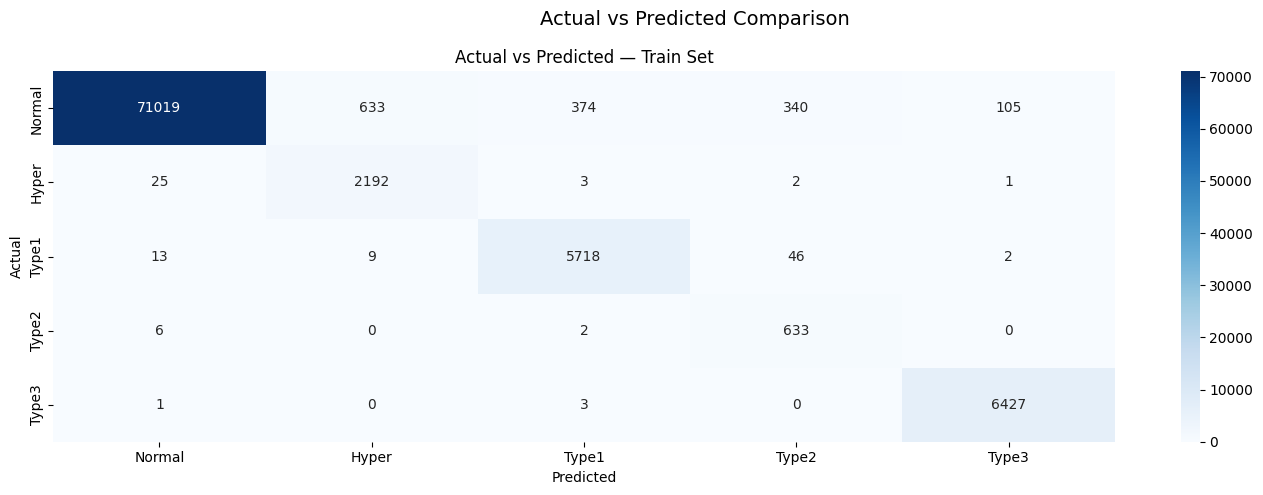

In [59]:
# Actual vs predicted train set
fig1, ax = plt.subplots(1,1, figsize=(14, 5))

cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Actual vs Predicted — Train Set')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.suptitle('Actual vs Predicted Comparison', fontsize=14)
plt.tight_layout()
plt.show()


### Bias-variance tradeoff assessment:


In [27]:
train_acc = np.mean(y_train_pred == y_train)
test_acc  = np.mean(y_test_pred  == y_test)

# gap < 2% between train and test accuracy means good generalisation:
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")
print(f"Gap:            {abs(train_acc - test_acc):.4f}")

Train accuracy: 0.9821
Test  accuracy: 0.9731
Gap:            0.0090


## Visualisations:


### Learning curves:

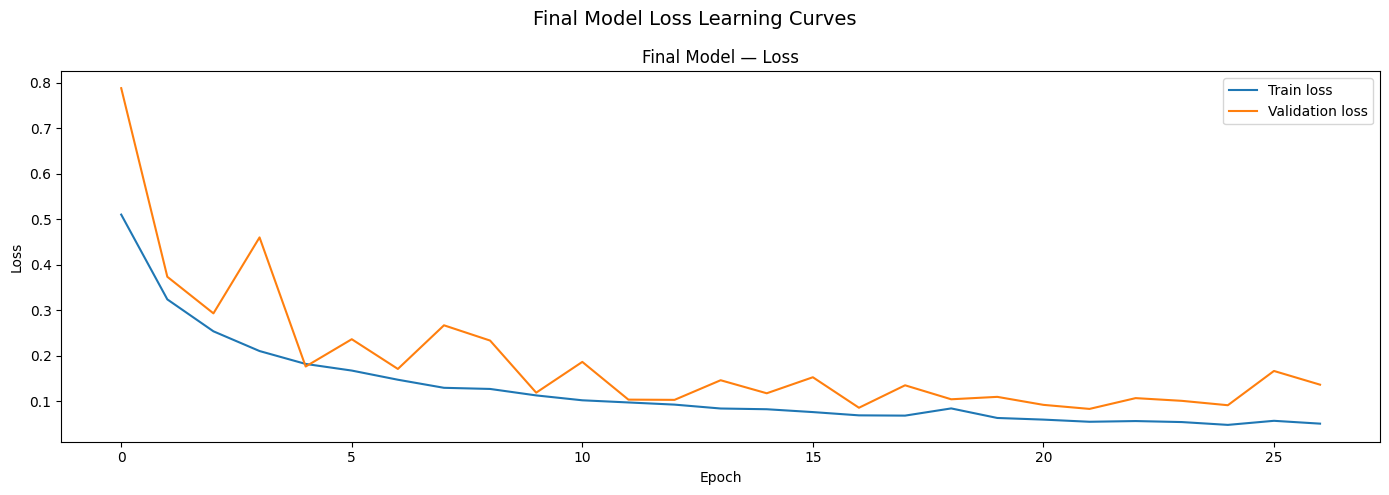

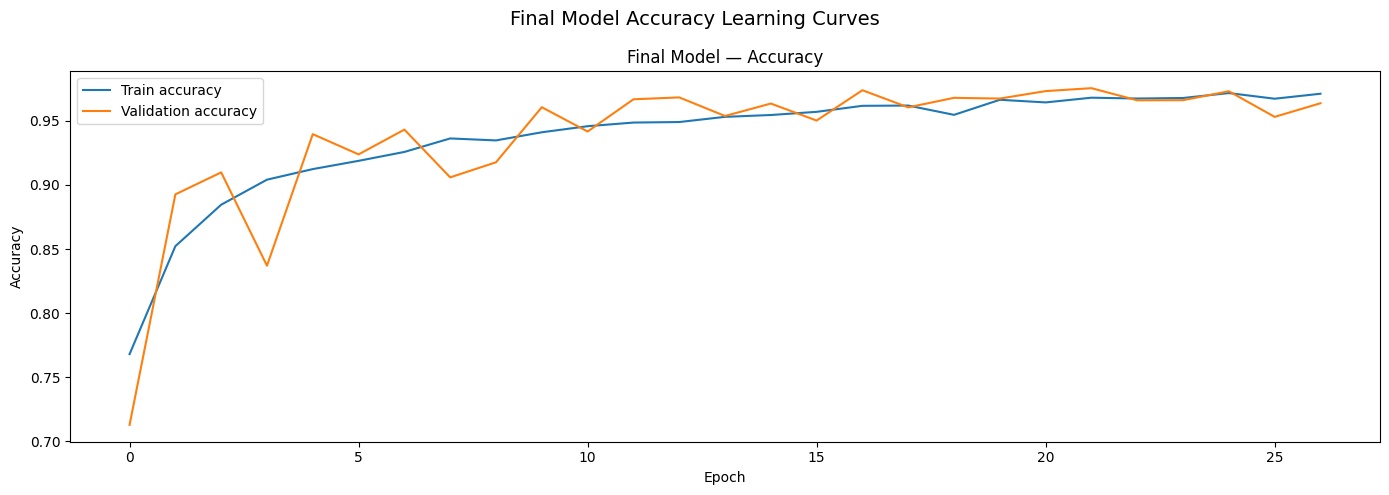

In [60]:
# Final model learning curves

fig2, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(final_history.history['loss'],     label='Train loss')
ax.plot(final_history.history['val_loss'], label='Validation loss')
ax.set_title('Final Model — Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

plt.suptitle('Final Model Loss Learning Curves', fontsize=14)
plt.tight_layout()
plt.show()

fig3, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(final_history.history['accuracy'],     label='Train accuracy')
ax.plot(final_history.history['val_accuracy'], label='Validation accuracy')
ax.set_title('Final Model — Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()

plt.suptitle('Final Model Accuracy Learning Curves', fontsize=14)
plt.tight_layout()
plt.show()

### Confusion Matrix

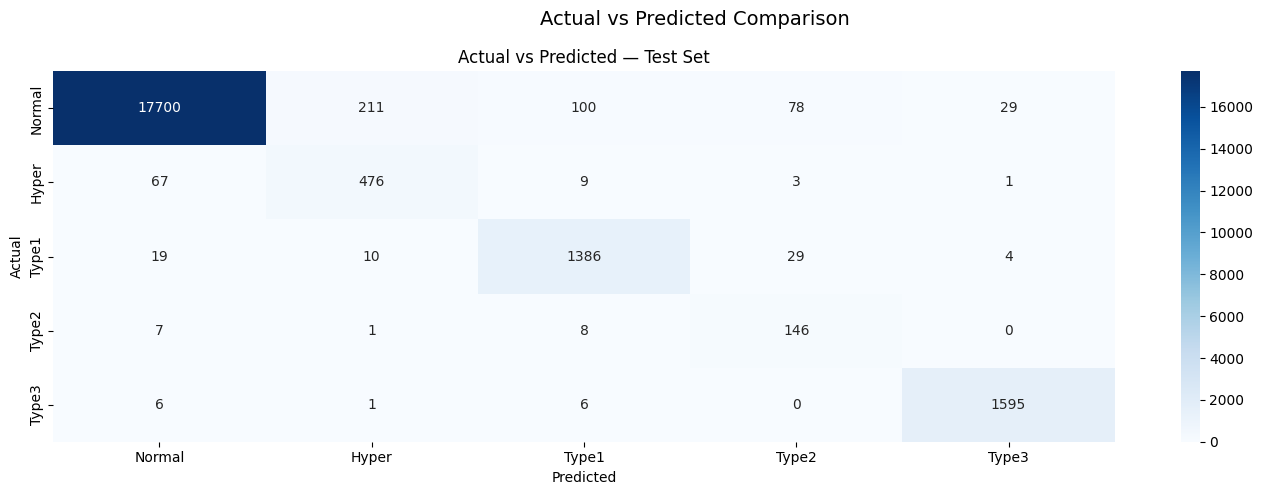

In [61]:

# Actual vs predicted test set
fig4, ax = plt.subplots(1, 1, figsize=(14, 5))

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Actual vs Predicted — Test Set')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.suptitle('Actual vs Predicted Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### Loss and Accuracy curves acrosss 5 folds

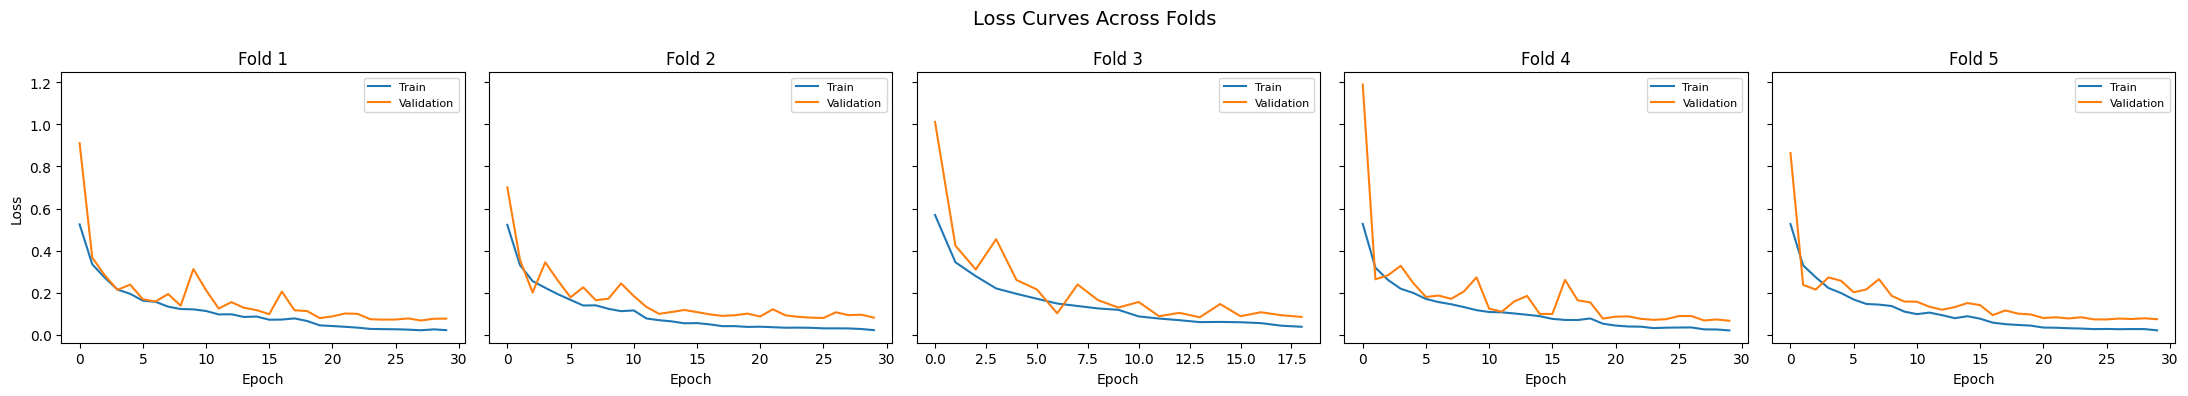

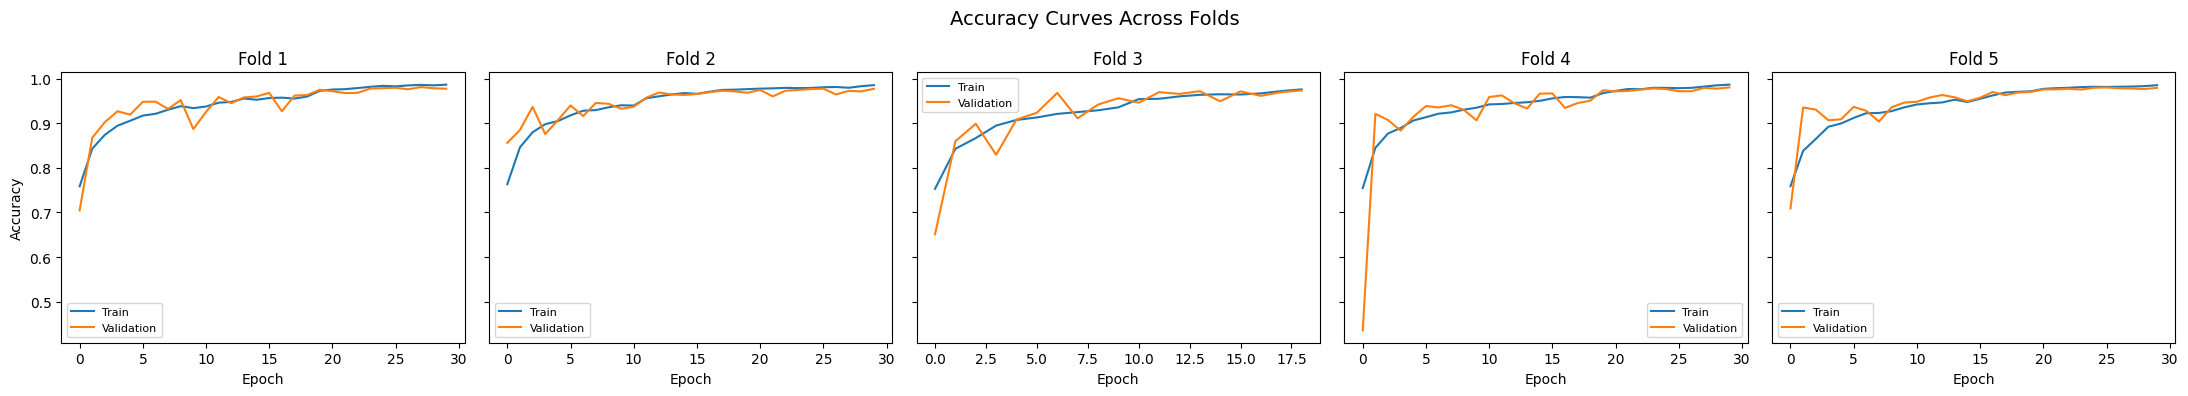

In [62]:
# Side-by-side fold loss curves
fig5, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)

best_idx = max(all_histories, key=lambda k: all_histories[k]['mean_val_acc'])
best_fold_histories = all_histories[best_idx]['histories']
for i, (ax, h) in enumerate(zip(axes, best_fold_histories)):
    ax.plot(h.history['loss'],     label='Train')
    ax.plot(h.history['val_loss'], label='Validation')
    ax.set_title(f'Fold {i + 1}')
    ax.set_xlabel('Epoch')
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8)

plt.suptitle('Loss Curves Across Folds', fontsize=14)
plt.tight_layout()
plt.show()

# Side-by-side fold accuracy curves
fig6, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)

for i, (ax, h) in enumerate(zip(axes, best_fold_histories)):
    ax.plot(h.history['accuracy'],     label='Train')
    ax.plot(h.history['val_accuracy'], label='Validation')
    ax.set_title(f'Fold {i + 1}')
    ax.set_xlabel('Epoch')
    if i == 0:
        ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)

plt.suptitle('Accuracy Curves Across Folds', fontsize=14)
plt.tight_layout()
plt.show()

## Save Model and Image curves:

In [55]:
#Save Final Model
final_model.save('ANNmodel.keras')

In [63]:
# Save figures for report
fig1.savefig('train_confusion_matrix.png',     dpi=150, bbox_inches='tight')
fig2.savefig('loss_learning_curves.png',      dpi=150, bbox_inches='tight')
fig3.savefig('accuracy_learning_curves.png',     dpi=150, bbox_inches='tight')
fig4.savefig('test_confusion_matrix.png',     dpi=150, bbox_inches='tight')
fig5.savefig('fold_loss_curves.png',     dpi=150, bbox_inches='tight')
fig6.savefig('fold_accuracy_curves.png', dpi=150, bbox_inches='tight')